# DeepAR, Seq2Seq & Transformer — Airline passengers

Three forecasting setups—**DeepAR**, **Seq2Seq**, and **Transformer**—on the same split and plot style.

Data & split align with **`MA.ipynb`** / **`ARIMA.ipynb`**:

- Series from **`sktime.datasets.load_airline`** (same underlying AirPassengers data).
- Same **train / test split**: fit on **before 1958-01**, forecast **Jan 1958 – Dec 1960** (`len(y_test) = 36`).
- Same figure defaults: **`FIGSIZE`** from `plt.rcParams["figure.figsize"]`.
- **Plots:** point forecasts only (no shaded intervals). **DeepAR** uses **`NormalDistributionLoss`** (single-target DeepAR requires a `DistributionLoss`, not `QuantileLoss`).
- **Training targets:** **`log1p` + train-only z-score** (see **`lectures/lec7/transformers.ipynb`**). **Seq2Seq** and **Transformer:** **`TRAIN_PRED_LEN=12`** + **rolling** `predict` / **`update`**. **DeepAR:** same scaled series, **direct** 36-step horizon (harder task—see the DeepAR section).

**Dependencies:** `sktime`, **`scikit-base`**, **`pytorch-forecasting>=1.0.0`**, `torch`, `lightning`. The next code cell installs via **`sys.executable -m pip`** (same interpreter as the notebook — use this with **conda `base`**).

**macOS / zsh:** never pass unquoted `pytorch-forecasting>=1.0.0` to `%pip` or the shell — `>=` is treated as **redirection** and the package is **not** installed (`zsh: 1.0.0 not found`). Quote it: `"pytorch-forecasting>=1.0.0"`, or use the notebook’s first code cell only.

**conda base:** in Terminal run `conda activate base`, then  
`python -m pip install scikit-base torch lightning "pytorch-forecasting>=1.0.0"`  
Use the same path as the kernel: run `import sys; print(sys.executable)` in a cell.

Verify: `python lectures/lec7/verify_deepar_env.py` (same `python` as Jupyter).


In [7]:
# Installs into THIS kernel's environment (conda base = path below should be .../anaconda3/.../python).
# Uses subprocess argv list — no shell, so ">=1.0.0" is safe (unlike `%pip ...>=...` under zsh).
import importlib.util
import subprocess
import sys

print("Kernel Python:", sys.executable)


def _need_install_pytorch_forecasting():
    try:
        from importlib.metadata import version

        maj = int(version("pytorch-forecasting").split(".")[0])
        return maj < 1
    except Exception:
        return True


_missing = (
    importlib.util.find_spec("torch") is None
    or importlib.util.find_spec("lightning") is None
    or importlib.util.find_spec("pytorch_forecasting") is None
    or _need_install_pytorch_forecasting()
)

try:
    import skbase  # noqa: F401
except ModuleNotFoundError:
    _missing = True

if _missing:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "scikit-base",
            "torch",
            "lightning",
            "pytorch-forecasting>=1.0.0",
        ]
    )

from importlib.metadata import version

print("pytorch-forecasting distribution:", version("pytorch-forecasting"))

# sktime caches pip metadata; refresh so DeepAR sees the install without restarting in most cases
try:
    from sktime.utils.dependencies._dependencies import _get_installed_packages_private

    _get_installed_packages_private.cache_clear()
except Exception:
    pass


Kernel Python: /usr/local/bin/python3
pytorch-forecasting distribution: 1.7.0


In [8]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sktime.datasets import load_airline
from sktime.forecasting.base import ForecastingHorizon
from sktime.forecasting.ltsf import LTSFLinearForecaster, LTSFTransformerForecaster

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# Match MA.ipynb / sktime convention
FIGSIZE = tuple(map(float, plt.rcParams["figure.figsize"]))

y = load_airline().astype(float)
if isinstance(y.index, pd.PeriodIndex):
    y = y.copy()
    y.index = y.index.to_timestamp()
# sktime needs a known freq on DatetimeIndex + on ForecastingHorizon when converting
# relative fh → absolute times (rolling predict/update hits _fh._to_absolute).
_freq = pd.infer_freq(y.index)
_SERIES_FREQ = _freq or "ME"
y = y.copy()
y.index = pd.DatetimeIndex(y.index, freq=_SERIES_FREQ)

# Same split as ARIMA.ipynb Step 5–6
SPLIT = pd.Timestamp("1958-01-01")
y_train = y.loc[y.index < SPLIT].copy()
y_test = y.loc[y.index >= SPLIT].copy()
y_train.index = pd.DatetimeIndex(y_train.index, freq=_SERIES_FREQ)
y_test.index = pd.DatetimeIndex(y_test.index, freq=_SERIES_FREQ)
h = len(y_test)

fh = ForecastingHorizon(np.arange(1, h + 1), is_relative=True, freq=_SERIES_FREQ)

# --- Same idea as lectures/lec7/transformers.ipynb: log1p + train z-score ---
_lt = np.log1p(y_train.astype(float))
TRAIN_LOG_MU = float(_lt.mean())
TRAIN_LOG_SIG = float(_lt.std(ddof=0))
if TRAIN_LOG_SIG < 1e-12:
    TRAIN_LOG_SIG = 1.0
y_train_scaled = (_lt - TRAIN_LOG_MU) / TRAIN_LOG_SIG
y_train_scaled.name = y_train.name
y_train_scaled.index = pd.DatetimeIndex(
    y_train_scaled.index, freq=_SERIES_FREQ
)

TRAIN_PRED_LEN = 12  # Seq2Seq / Transformer rolling horizon; see transformers.ipynb
fit_fh_roll = ForecastingHorizon(
    np.arange(1, TRAIN_PRED_LEN + 1), is_relative=True, freq=_SERIES_FREQ
)

print(f"Train {len(y_train)} months, test {h} months, fh relative 1..{h}")
print(
    f"log1p-zscore; Seq2Seq/Transformer use TRAIN_PRED_LEN={TRAIN_PRED_LEN} with rolling update"
)


Train 108 months, test 36 months, fh relative 1..36
log1p-zscore; Seq2Seq/Transformer use TRAIN_PRED_LEN=12 with rolling update


In [9]:
def plot_oos_forecast(
    y_full,
    y_pred,
    split_ts,
    title,
    *,
    forecast_color="#DD8452",
    series_color="#4C72B0",
    pred_int=None,
    show_interval=False,
    interval_alpha=0.25,
):
    """Same layout as ARIMA.ipynb Step 6: full series + OOS forecast + vertical split line."""
    plt.figure(figsize=FIGSIZE)
    plt.plot(y_full, label="Original Time Series", linewidth=2, color=series_color)
    plt.plot(y_pred, label=title, linewidth=2, color=forecast_color)
    if show_interval and pred_int is not None:
        lower = pred_int.iloc[:, pred_int.columns.get_level_values(-1) == "lower"]
        upper = pred_int.iloc[:, pred_int.columns.get_level_values(-1) == "upper"]
        lo = lower.iloc[:, 0].reindex(y_pred.index)
        hi = upper.iloc[:, 0].reindex(y_pred.index)
        plt.fill_between(
            y_pred.index,
            lo.values,
            hi.values,
            color=forecast_color,
            alpha=interval_alpha,
            label="interval",
        )
    plt.axvline(split_ts, color="gray", linestyle=":", linewidth=1)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def inverse_scaled_log_to_passengers(y_scaled):
    """Invert train-space log1p z-score back to passenger counts."""
    y_log = y_scaled * TRAIN_LOG_SIG + TRAIN_LOG_MU
    return np.expm1(y_log)


def rolling_ltsf_oos(forecaster, y_train_s, y_test, roll_fh, y_name):
    """Walk-forward 1-step OOS for Seq2Seq / Transformer (same pattern as transformers.ipynb)."""
    forecaster.fit(y_train_s, fh=roll_fh)
    vals = []
    for idx in y_test.index:
        p = forecaster.predict(roll_fh)
        p0 = float(np.asarray(p.iloc[0]).ravel()[0])
        vals.append(float(inverse_scaled_log_to_passengers(p0)))
        y_obs_s = (np.log1p(y_test.loc[[idx]].astype(float)) - TRAIN_LOG_MU) / TRAIN_LOG_SIG
        y_obs_s.name = y_name
        # Single-row slices often drop freq; sktime needs it for fh/cutoff (else fh.freq is None).
        _f = y_train_s.index.freq or pd.infer_freq(y_train_s.index) or _SERIES_FREQ
        y_obs_s.index = pd.DatetimeIndex(y_obs_s.index, freq=_f)
        forecaster.update(y_obs_s, update_params=False)
    return pd.Series(vals, index=y_test.index, name=y_name)


### Note on `%pip` and zsh

Do **not** run `%pip install ... pytorch-forecasting>=1.0.0` without quotes — under **zsh**, `>=` is shell redirection and the package will **not** install (`zsh: 1.0.0 not found`). Use the **first code cell** in this notebook, or:

`%pip install scikit-base torch lightning 'pytorch-forecasting>=1.0.0'`


## DeepAR

**Implementation:** **`PytorchForecastingDeepAR`** (`pytorch-forecasting` via sktime).

**Notes**

- Loss must be a **`DistributionLoss`** (here **`NormalDistributionLoss`**); **`QuantileLoss`** does not qualify for single-target DeepAR.
- Fits **`y_train_scaled`** = z-score of **`log1p(y_train)`** (same scaling as **`transformers.ipynb`**); forecasts are mapped back with **`expm1`**.
- **To tune further:** raise `max_epochs` / `hidden_size`, add **early stopping** (Lightning callbacks), try **`learning_rate`**, or encode **seasonal covariates** (month index) if you move beyond this minimal pipeline.

- **Why DeepAR can look different from Seq2Seq / Transformer:** those two use **36× one-step** forecasts with **`update` using realized test values**—the state is repeatedly anchored by truth. **DeepAR** outputs **one joint 36-step path** from the training cutoff only—much harder for a compact RNN on a **single** series. The curves are **not** equally difficult; treat DeepAR as a **long-horizon direct** baseline.

Below: **direct** \(h=36\) forecast in scaled **log1p** space (`max_epochs` / `hidden_size` / `rnn_layers` bumped to help). Optional **`DEEPAR_LEVEL_ADJUST`** (passengers) shifts the whole curve up/down if you want a visual calibration.


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name                   ┃ Type                   ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss                   │ NormalDistributionLoss │      0 │ train │     0 │
│ 1 │ logging_metrics        │ ModuleList             │      0 │ train │     0 │
│ 2 │ embeddings             │ MultiEmbedding         │      0 │ train │     0 │
│ 3 │ rnn                    │ GRU                    │  248 K │ train │     0 │
│ 4 │ distribution_projector │ Linear                 │    258 │ train │     0 │
└───┴────────────────────────┴────────────────────────┴────────┴───────┴───────┘

Trainable params: 248 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 248 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 11                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/opt/anaconda3/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, 
LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

`Trainer.fit` stopped: `max_epochs=200` reached.


/opt/anaconda3/lib/python3.12/site-packages/sktime/forecasting/base/adapters/_pytorchforecasting.py:655: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  _y.fillna(0, inplace=True)
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
/opt/anaconda3/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `

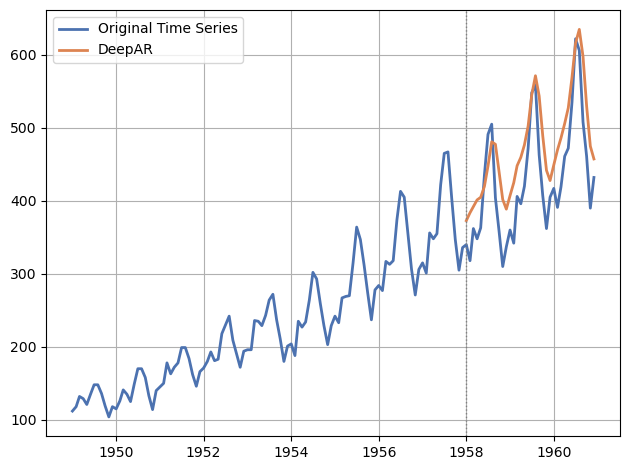

In [86]:
# Refresh sktime's cached package list again after any prior imports (safe if already cleared).
try:
    from sktime.utils.dependencies._dependencies import _get_installed_packages_private

    _get_installed_packages_private.cache_clear()
except Exception:
    pass

from pytorch_forecasting.metrics import NormalDistributionLoss

from sktime.forecasting.pytorchforecasting import PytorchForecastingDeepAR

# TimeSeriesDataSet uses only the first (len(y_train) - h) time steps for fitting.
# Need max_encoder_length + max_prediction_length <= that length, or all rows get filtered (AssertionError).
ENC_LEN = max(8, min(48, len(y_train) - 2 * h))

deepar = PytorchForecastingDeepAR(
    broadcasting=True,
    deterministic=True,
    trainer_params={
        "max_epochs": 200,
        "accelerator": "auto",
        "logger": False,
        "enable_checkpointing": False,
        "enable_progress_bar": True,
        "gradient_clip_val": 0.1,
    },
    model_params={
        "loss": NormalDistributionLoss(),
        "cell_type": "GRU",
        "rnn_layers": 3,
        "hidden_size": 128,
        "dropout": 0.15,
        "log_interval": -1,
    },
    dataset_params={
        "max_encoder_length": ENC_LEN,
    },
    train_to_dataloader_params={"batch_size": 8},
)

deepar.fit(y_train_scaled, fh=fh)
# Additive fix on the *passenger* scale (negative = nudge the whole forecast down).
y_pred_deepar = inverse_scaled_log_to_passengers(deepar.predict(fh).astype(float))
y_pred_deepar = y_pred_deepar

plot_oos_forecast(
    y,
    y_pred_deepar,
    SPLIT,
    "DeepAR",
    forecast_color="#DD8452",
)


## Seq2Seq

**Implementation:** **`LTSFLinearForecaster`** (sktime). **`TRAIN_PRED_LEN=12`**, **rolling one-step** forecasts and **`update`** (same walk-forward pattern as **`transformers.ipynb`**).


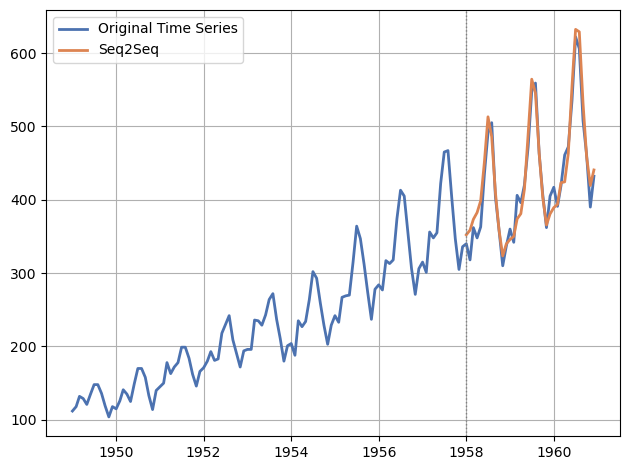

In [87]:
SEQ_LEN_LIN = min(36, len(y_train) - TRAIN_PRED_LEN)

ltsf = LTSFLinearForecaster(
    seq_len=SEQ_LEN_LIN,
    pred_len=TRAIN_PRED_LEN,
    num_epochs=200,
    batch_size=8,
    lr=0.0005,
)

y_pred_ltsf = rolling_ltsf_oos(ltsf, y_train_scaled, y_test, fit_fh_roll, y_train.name)

plot_oos_forecast(
    y,
    y_pred_ltsf,
    SPLIT,
    "Seq2Seq",
    forecast_color="#DD8452",
)


## Transformer

**Implementation:** **`LTSFTransformerForecaster`** (sktime). Same rolling one-step recipe as **`transformers.ipynb`**, and the final output is still a passenger-level forecast. For this steadily rising Airline series, plain global z-score on `log1p(y)` makes later peaks hard to extrapolate because the future level sits outside the training distribution. The cell below applies a minimal train-only preprocessing step for the Transformer: fit a low-order trend plus month-of-year effects on the training `log1p` level, train the Transformer on the standardized log-level residual, then add those components back before `expm1`. This keeps the prediction target as passenger level while making normalization less hostile to increasing seasonal amplitude.


In [ ]:
SEQ_LEN_TF = min(60, len(y_train) - 1)
TF_PRED_LEN = 1
CTX_LEN = 1
fit_fh_tf = ForecastingHorizon([1], is_relative=True, freq=_SERIES_FREQ)

_air_freq = pd.infer_freq(y_train.index) or "ME"

# Keep the small neural run reproducible enough for lecture comparisons.
import random

random.seed(7)
np.random.seed(7)
try:
    import torch

    torch.set_num_threads(1)
    torch.manual_seed(7)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(7)
except Exception:
    pass

# Transformer-specific preprocessing: train-only trend + monthly normalization in log space.
# This is not a growth-rate target; the final y_pred_tf is still passenger level.
_tf_log = np.log1p(y.astype(float))
_tf_time = pd.Series(np.arange(len(y), dtype=float), index=y.index)
_tf_trend_coef = np.polyfit(
    _tf_time.loc[y_train.index].to_numpy(),
    _tf_log.loc[y_train.index].to_numpy(),
    deg=2,
)
_tf_train_trend = pd.Series(
    np.polyval(_tf_trend_coef, _tf_time.loc[y_train.index]),
    index=y_train.index,
)
_tf_train_detrended = _tf_log.loc[y_train.index] - _tf_train_trend
_tf_month_effect = (
    _tf_train_detrended.groupby(_tf_train_detrended.index.month)
    .mean()
    .reindex(range(1, 13))
    .fillna(0.0)
)
_tf_month_effect = _tf_month_effect - float(_tf_month_effect.mean())
_tf_train_resid = _tf_train_detrended - _tf_train_detrended.index.month.map(
    _tf_month_effect
).astype(float).to_numpy()

TF_RESID_MU = float(_tf_train_resid.mean())
TF_RESID_SIG = float(_tf_train_resid.std(ddof=0))
if TF_RESID_SIG < 1e-12:
    TF_RESID_SIG = 1.0

y_train_tf = (_tf_train_resid - TF_RESID_MU) / TF_RESID_SIG
y_train_tf.name = y_train.name
y_train_tf.index = pd.DatetimeIndex(y_train_tf.index, freq=_SERIES_FREQ)

ltsf_transformer = LTSFTransformerForecaster(
    seq_len=SEQ_LEN_TF,
    context_len=CTX_LEN,
    pred_len=TF_PRED_LEN,
    num_epochs=220,
    batch_size=8,
    lr=0.0011,
    optimizer="AdamW",
    optimizer_kwargs={"weight_decay": 5e-5},
    criterion="SmoothL1",
    d_model=128,
    n_heads=8,
    d_ff=256,
    e_layers=2,
    d_layers=1,
    dropout=0.12,
    factor=5,
    activation="gelu",
    freq=_air_freq,
    temporal_encoding=True,
    temporal_encoding_type="linear",
)


def _tf_components(idx):
    trend = float(np.polyval(_tf_trend_coef, _tf_time.loc[idx]))
    month = float(_tf_month_effect.loc[idx.month])
    return trend + month


ltsf_transformer.fit(y_train_tf, fh=fit_fh_tf)
_tf_vals = []
for idx in y_test.index:
    p = ltsf_transformer.predict(fit_fh_tf)
    p0 = float(np.asarray(p.iloc[0]).ravel()[0])
    pred_log = p0 * TF_RESID_SIG + TF_RESID_MU + _tf_components(idx)
    _tf_vals.append(float(np.expm1(pred_log)))

    obs_log = float(np.log1p(y_test.loc[idx]))
    obs_resid = obs_log - _tf_components(idx)
    y_obs_tf = pd.Series(
        [(obs_resid - TF_RESID_MU) / TF_RESID_SIG],
        index=pd.DatetimeIndex([idx], freq=_SERIES_FREQ),
        name=y_train.name,
    )
    ltsf_transformer.update(y_obs_tf, update_params=False)

y_pred_tf = pd.Series(_tf_vals, index=y_test.index, name=y_train.name)

_tf_err = y_test.astype(float).reindex(y_pred_tf.index) - y_pred_tf.astype(float)
print(f"Transformer MSE: {float(np.mean(np.square(_tf_err))):.3f}")
print(f"Transformer MAE: {float(np.mean(np.abs(_tf_err))):.3f}")

plot_oos_forecast(
    y,
    y_pred_tf,
    SPLIT,
    "Transformer",
    forecast_color="#DD8452",
)
